# Clasificación de lenguaje de señas mediante un Perceptrón Multicapa (MLP)

---
## 1. Introducción y definición del problema

El proyecto aborda un problema de **clasificación multiclase de imágenes de lenguaje de señas**. Cada imagen representa una configuración de la mano asociada a una clase. El objetivo es entrenar una red neuronal tipo **Perceptrón Multicapa (MLP)** capaz de recibir los valores de intensidad de los píxeles y predecir la clase correspondiente.

## 2. Objetivos del proyecto

### Objetivo general
Desarrollar y evaluar un modelo MLP capaz de clasificar imágenes de lenguaje de señas a partir de sus valores de píxeles.

### Objetivos específicos
- Comprender la estructura y características de los datasets.
- Analizar la distribución de las clases y la calidad de los datos.
- Normalizar y preparar los píxeles para el entrenamiento.
- Diseñar una arquitectura MLP adecuada para un problema multiclase.
- Entrenar el modelo utilizando un conjunto de entrenamiento y otro de validación.
- Evaluar el desempeño mediante Accuracy, Precision, Recall, F1-Score y matriz de confusión.
- Analizar ejemplos correctamente e incorrectamente clasificados.
- Identificar las limitaciones de una arquitectura MLP aplicada a imágenes y proponer mejoras.

## 3. KPIs

Para evaluar el modelo se utilizarán los siguientes indicadores:

| KPI | Propósito |
|---|---|
| **Accuracy** | Proporción total de imágenes clasificadas correctamente. |
| **Precision** | Qué tan confiables son las predicciones realizadas para cada clase. |
| **Recall** | Capacidad del modelo para recuperar correctamente las imágenes pertenecientes a cada clase. |
| **F1-Score** | Balance entre Precision y Recall. |
| **Matriz de confusión** | Permite identificar qué clases se confunden entre sí. |

## 4. Instalación y carga de librerías
Para trabajar de manera local este notebook, se requiere tener instaladas las siguientes librerías: `numpy`, `pandas`, `matplotlib.pyplot`, `tensorflow` y `seabron`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import keras
from tensorflow import keras
from sklearn.metrics import classification_report,confusion_matrix

## 5. Fuente y estructura de los datos

Se utilizan dos archivos CSV:

- `sign_mnist_train.csv`: datos destinados al entrenamiento y de los cuales se separará un subconjunto de validación.
- `sign_mnist_test.csv`: datos reservados para la evaluación final.

Los archivos contienen **27.455 registros de entrenamiento** y **7.172 registros de prueba**, con 785 columnas cada uno: una columna `label` y 784 columnas de píxeles.

In [4]:
# carga de los datos para entrenamiento y test.
import os 
print(os.getcwd())
datos_entrenamiento = pd.read_csv('../data/sign_mnist_train/sign_mnist_train.csv')
print(os.path.exists('../data/sign_mnist_train/sign_mnist_train.csv'))
datos_prueba = pd.read_csv('../data/sign_mnist_test/sign_mnist_test.csv')
print(os.path.exists('../data/sign_mnist_test/sign_mnist_test.csv'))

/home/rodricac/Documents/Duouc26_semes2/Tecnicas avanzadas MachineLearning/MLAIimages/proyectAI/notebooks
True
True


## 6. Comprensión y análisis exploratorio de los datos (EDA)

En esta etapa se revisan las dimensiones de los datasets, tipos de datos, número de clases, distribución de ejemplos y estadísticas de los píxeles. Además, se visualizan imágenes representativas para comprobar que los vectores de 784 valores pueden interpretarse como imágenes de 28 × 28 píxeles.

In [5]:
# dimension de datos en entrenamiento 
print(f'''
Datos entrenamiento
dimension: {datos_entrenamiento.shape}
cantidad de datos : {datos_entrenamiento.shape[0]} imagenes
dimension de cada imagen: {datos_entrenamiento.shape[1]} pixeles por imagen''')


Datos entrenamiento
dimension: (27455, 785)
cantidad de datos : 27455 imagenes
dimension de cada imagen: 785 pixeles por imagen


In [6]:
# dimension de datos en prueba
print(f'''
Datos Prueba
dimension: {datos_prueba.shape}
cantidad de datos : {datos_prueba.shape[0]} imagenes
dimension de cada imagen: {datos_prueba.shape[1]} pixeles por imagen''')


Datos Prueba
dimension: (7172, 785)
cantidad de datos : 7172 imagenes
dimension de cada imagen: 785 pixeles por imagen


In [7]:
# Informacion detallada en datos de entrenamiento.
print(f'''datos entrenamiento:{datos_entrenamiento.info()}''')

<class 'pandas.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
datos entrenamiento:None


In [8]:
# informacion detallada en dato de prueba.
print(f'''Datos de prueba: {datos_prueba.info()}''')

<class 'pandas.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 43.0 MB
Datos de prueba: None


In [9]:
# Cantidad de pixeles de la imagen y su dimension
print(f'''Cantidad de pixeles de la imagen: {datos_entrenamiento.shape[1]-1}
dimension: {np.sqrt(datos_entrenamiento.shape[1]-1)}
dimension imagen: {int(np.sqrt(datos_entrenamiento.shape[1]-1))} X {int(np.sqrt(datos_entrenamiento.shape[1]-1))}''')

Cantidad de pixeles de la imagen: 784
dimension: 28.0
dimension imagen: 28 X 28


In [10]:
# label, variable objetivo , verificamos los valores unicos para encontrar la cantidad de clases
clases = datos_entrenamiento['label'].unique()
clases

array([ 3,  6,  2, 13, 16,  8, 22, 18, 10, 20, 17, 19, 21, 23, 24,  1, 12,
       11, 15,  4,  0,  5,  7, 14])

In [11]:
# Separacion de datos para entramiento.
features_train = datos_entrenamiento.drop(columns='label')
label_train = datos_entrenamiento['label']

print(f'''Chequeo de dimensiones entrenamiento, features and label
features : {features_train.shape}
label : {label_train.shape}''')

Chequeo de dimensiones entrenamiento, features and label
features : (27455, 784)
label : (27455,)


In [12]:
# Separacion de datos para test
features_test = datos_prueba.drop(columns='label')
label_test= datos_prueba['label']
print(f'''
Chequeo de dimension para test. fetures_tes and label_test
features_test : {features_test.shape}
label_test: {label_test.shape}''')


Chequeo de dimension para test. fetures_tes and label_test
features_test : (7172, 784)
label_test: (7172,)


In [13]:
# El describe nos proporciona un resumen estadisticos de las variables numericas.
# incluyendo las medidas de media central.
# dispersion y posicion.
features_train.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,165.533673,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,31.279244,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,148.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,167.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,186.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


## 7. Preparación y preprocesamiento de los datos

Antes de poder entrenar un modelo, los datos deben prepararse. En este proyecto la preparación consiste en:

1. **Separar** las características (los 784 píxeles) de la variable objetivo (`label`).
2. **Normalizar** los valores de los píxeles, llevándolos del rango original [0, 255] al rango [0, 1]. Esto ayuda a que el modelo entrene de forma más estable, porque evita que los valores numéricos de entrada sean demasiado grandes.

In [14]:
# funcion normalizar
def normalizar(imagenes, etiquetas):
    """toma las imagenes como caracteristicas y 
    sus etiquetas correspondientes a la clase de cada imagen.
    las imagenes se convierten a un tipo de datos flotante y sus valores de intensidad
    originalmente va desde 0 a 255 valores de intensidad y se normalizan a un rango de 0 a 1.
    Args:
        imagenes (float64): caracteristica de cada imagen representadas
        mediante sus valores de pixeles.
        etiquetas (float64): clase correspondiente a cada imagen.

    Returns:
        float64: retorna un tupla que contiene los valores de intensidad normalizados
        en un rango de 0 a 1 y las etiquetas quedan sin modificar.
    """    
    imagenes = tf.cast(imagenes,tf.float32)
    imagenes/=255
    return imagenes,etiquetas

- El siguiente tratamiento realizara una normalizacion para los valores de los pixeles en cada imagen.
Donde cada imagen esta compuesta por una dimension 784 pixeles, correspondiente a una dimension de 28x28, la intensidad de los valores de los pixeles se encuentran en un rango de 0-255, por lo que seran normalizados en un rango de 0 a 1.

In [15]:
# Normalizacion de los datos para entrenamiento y test
#train
normalized_train, label_train = normalizar(features_train,label_train)
#test
normalized_test , label_test = normalizar(features_test,label_test)

E0000 00:00:1788725947.050860   11613 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1788725950.491154   11613 cpu_allocator_impl.cc:82] Allocation of 172197760 exceeds 10% of free system memory.
W0000 00:00:1788725950.795206   11613 cpu_allocator_impl.cc:82] Allocation of 86098880 exceeds 10% of free system memory.
W0000 00:00:1788725950.888281   11613 cpu_allocator_impl.cc:82] Allocation of 86098880 exceeds 10% of free system memory.
W0000 00:00:1788725951.184246   11613 cpu_allocator_impl.cc:82] Allocation of 44982784 exceeds 10% of free system memory.


### Distribución de Clases

In [16]:
class_distribution = label_train.value_counts(ascending=False)
difference = class_distribution.max() - class_distribution.min()
print(f'''
distribucion de clases : {class_distribution}
diferencia de clases con mayor imagen y menor imagen
{difference}''')



distribucion de clases : label
17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
3     1196
14    1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64
diferencia de clases con mayor imagen y menor imagen
337


In [17]:
train_counts = {}
for class_number in clases:
    train_counts[class_number] = label_train.value_counts()[class_number]

train_counts


{np.int64(3): np.int64(1196),
 np.int64(6): np.int64(1090),
 np.int64(2): np.int64(1144),
 np.int64(13): np.int64(1151),
 np.int64(16): np.int64(1279),
 np.int64(8): np.int64(1162),
 np.int64(22): np.int64(1225),
 np.int64(18): np.int64(1199),
 np.int64(10): np.int64(1114),
 np.int64(20): np.int64(1161),
 np.int64(17): np.int64(1294),
 np.int64(19): np.int64(1186),
 np.int64(21): np.int64(1082),
 np.int64(23): np.int64(1164),
 np.int64(24): np.int64(1118),
 np.int64(1): np.int64(1010),
 np.int64(12): np.int64(1055),
 np.int64(11): np.int64(1241),
 np.int64(15): np.int64(1088),
 np.int64(4): np.int64(957),
 np.int64(0): np.int64(1126),
 np.int64(5): np.int64(1204),
 np.int64(7): np.int64(1013),
 np.int64(14): np.int64(1196)}

In [18]:
print(len(label_train))
print(len(label_test))

27455
7172


In [19]:
test_counts={}
for test_number in clases:
    test_counts[test_number] = label_test.value_counts()[test_number]
test_counts


{np.int64(3): np.int64(245),
 np.int64(6): np.int64(348),
 np.int64(2): np.int64(310),
 np.int64(13): np.int64(291),
 np.int64(16): np.int64(164),
 np.int64(8): np.int64(288),
 np.int64(22): np.int64(206),
 np.int64(18): np.int64(246),
 np.int64(10): np.int64(331),
 np.int64(20): np.int64(266),
 np.int64(17): np.int64(144),
 np.int64(19): np.int64(248),
 np.int64(21): np.int64(346),
 np.int64(23): np.int64(267),
 np.int64(24): np.int64(332),
 np.int64(1): np.int64(432),
 np.int64(12): np.int64(394),
 np.int64(11): np.int64(209),
 np.int64(15): np.int64(347),
 np.int64(4): np.int64(498),
 np.int64(0): np.int64(331),
 np.int64(5): np.int64(247),
 np.int64(7): np.int64(436),
 np.int64(14): np.int64(246)}

In [20]:
pd.set_option('display.max_rows',None)
difference_class = pd.DataFrame(
    {
        "class":clases,
        "train_counts" : [train_counts[c] for c in clases],
        "test_counts" : [test_counts[c] for c in clases]
    }
)
difference_class

,class,train_counts,test_counts
0,3,1196,245
1,6,1090,348
2,2,1144,310
3,13,1151,291
4,16,1279,164
5,8,1162,288
6,22,1225,206
7,18,1199,246
8,10,1114,331
9,20,1161,266


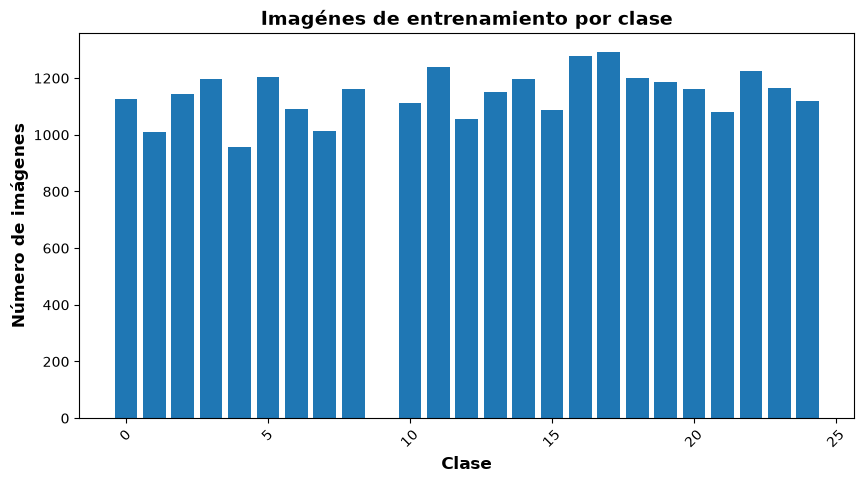

In [21]:
plt.figure(figsize=(10,5))
plt.bar(
    difference_class['class'],
    difference_class['train_counts']
)
plt.title("Imagénes de entrenamiento por clase", fontsize=14, fontweight="bold")
plt.xlabel("Clase", fontsize=12, fontweight="bold")
plt.ylabel("Número de imágenes", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

In [22]:
difference_class_long = difference_class.melt(
    id_vars="class",
    value_vars=['train_counts','test_counts']
)
difference_class_long.head()

,class,variable,value
0,3,train_counts,1196
1,6,train_counts,1090
2,2,train_counts,1144
3,13,train_counts,1151
4,16,train_counts,1279


In [23]:
difference_class_long['dataset'] = difference_class_long['variable'].map({
    'train_counts': 'Entrenamiento',
    'test_counts': 'Prueba'
})

Text(0.5, 1.0, 'Distribución de clases: entrenamiento vs prueba')

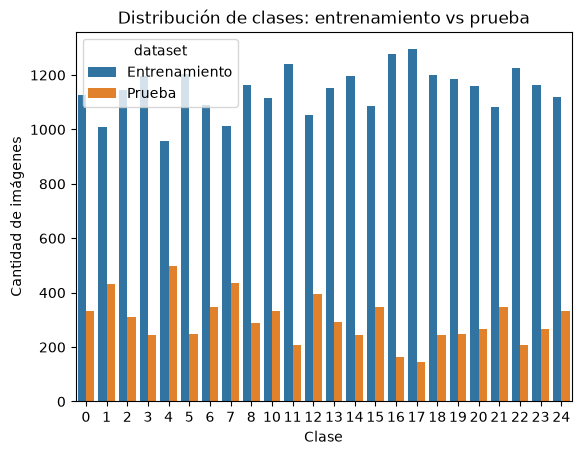

In [24]:
sns.barplot(data=difference_class_long,x='class',y='value',hue='dataset')
plt.ylabel('Cantidad de imágenes')
plt.xlabel('Clase')
plt.title('Distribución de clases: entrenamiento vs prueba')

# Normalizar Datos Originales

In [25]:
# al normalizar los datos originales, las caracteristicas se convierten en tensores,por lo tanto se procede a construir un dataset.
# para organizar las caracteristicas y etiquetas.
# dataset train
dataset_train = tf.data.Dataset.from_tensor_slices((normalized_train,label_train))
# dataset test
dataset_test = tf.data.Dataset.from_tensor_slices((normalized_test,label_test))

In [26]:
# Aquí usamos el reshape para darle a TensorFlow la estructura de las imágenes.
# Esto se realiza porque inicialmente cada imagen está representada como
# un vector de 784 píxeles. Como sabemos que 784 = 28 x 28, reorganizamos
# esos valores para que TensorFlow interprete cada imagen como una matriz
# de 28 x 28 píxeles.
x_train  = tf.reshape(normalized_train,(-1,28,28,1))
x_test = tf.reshape(normalized_test,(-1,28,28,1))
print(f'''Tensores de 4 dimensiones:
Tensor train : {x_train.shape}
Tensor test : {x_test.shape}''')

Tensores de 4 dimensiones:
Tensor train : (27455, 28, 28, 1)
Tensor test : (7172, 28, 28, 1)


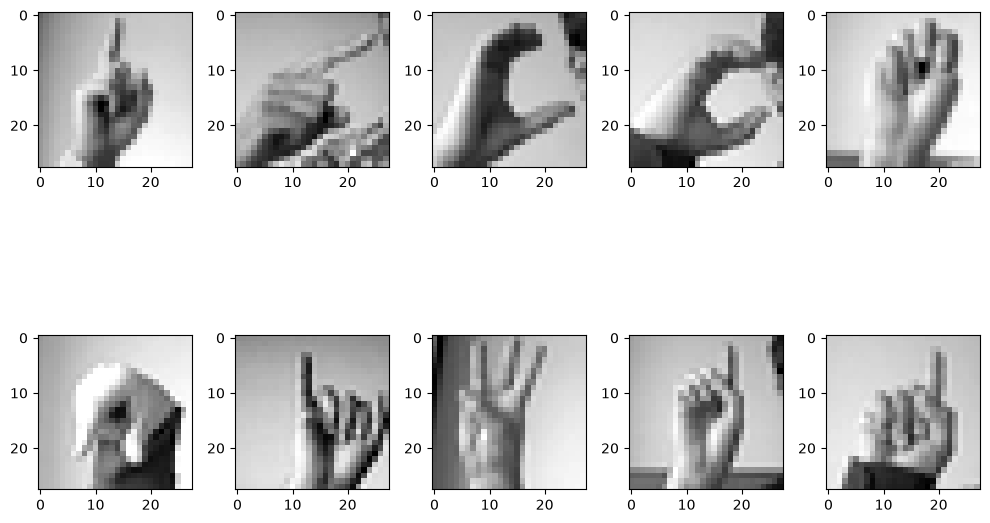

In [27]:
f, ax = plt.subplots(2,5) # mostramos 10 imagenes su dimension es de 2x5, es decir 2 filas x 5 columnas.
f.set_size_inches(10,10) # modificar tamano a pulgadas.
k = 0 # k es nuestro indice para decir que imagen debe mostrar de x_train.
for i in range(2):
    for j in range(5):
# como x_train[k] pide una imagen y nuestra estructura es de 4d, aqui reshape dice que solo quiere la dimension de la imagen que es de 28x28.
# y temporalmente se quita el canal 1.
        ax[i,j].imshow(tf.reshape(x_train[k],(28,28)), cmap='gray')
        k+=1 # aumentamos en indice de k en 1 hasta llegar a 10 que es el total de imagenes que queremos.
    plt.tight_layout()

## 8. Diseño del Perceptrón Multicapa (MLP)

La idea de un MLP (Perceptrón Multicapa) es que sea una red donde cada neurona de una capa está conectada con **todas** las neuronas de la capa siguiente.

```text
Entrada: imagen de 28x28x1
        ↓
Flatten (aplana la imagen a un vector de 784 valores)
        ↓
Dense(128, activación ReLU)   <- primera capa oculta
        ↓
Dense(64, activación ReLU)    <- segunda capa oculta
        ↓
Dense(25, activación Softmax) <- capa de salida
```

### Justificación de cada decisión

- **`Flatten`**: un MLP no puede recibir una imagen 2D directamente; primero hay que aplicar una transformación de dimensionalidad en un vector de 784 números (28 × 28).
- **Dos capas ocultas (128 y 64 neuronas)**: dan al modelo suficiente capacidad para combinar los 784 valores de entrada y aprender patrones que diferencien una letra de otra, sin hacer la red demasiado grande para el tamaño del dataset (aproximadamente 27.000 imágenes).
- **Activación ReLU en las capas ocultas**: la función de activación ReLU se seleccionó porque mantiene intactos los valores positivos en lugar de acotarlos, lo que mitiga el problema del desvanecimiento del gradiente gracias a su derivada constante de \(1\). Esta propiedad matemática garantiza un flujo de gradiente estable y un aprendizaje efectivo a través de la arquitectura del modelo. Además, al tratarse de una operación matemática simple y directa, ofrece una alta eficiencia computacional idónea para procesar las 27.455 imágenes de entrenamiento por época de forma rápida.
- **Capa de salida con 25 neuronas y activación Softmax**: `Softmax` convierte los 25 números de salida en probabilidades que suman 1, y la clase con mayor probabilidad es la predicción final del modelo.

## Remapeo de etiquetas

In [28]:
# # Remapeo de etiquetas
labels = [i for i in range(25) if i != 9]

mapping = {label: i for i, label in enumerate(labels)}

label_train = np.array([mapping[label] for label in label_train])
label_test = np.array([mapping[label] for label in label_test])

# # validacion 
print(np.unique(label_train))
print(np.unique(label_test))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


## Modelo Red Neuronal

## 9. Compilación del modelo: función de pérdida, optimizador y métrica


- **`loss='sparse_categorical_crossentropy'`**: es la función de pérdida estándar para clasificación multiclase cuando las etiquetas son números enteros (0, 1, 2, ...) en lugar de vectores one-hot. Mide qué tan alejada está la probabilidad que el modelo le asignó a la clase correcta, del valor ideal (100%).
- **`optimizer=Adam(0.1)`**: Adam es un algoritmo que ajusta automáticamente el tamaño de los "pasos" que da el modelo para reducir el error en cada iteración. El número `0.1` es la **tasa de aprendizaje (learning rate)**: define qué tan grande es cada paso.
- **`metrics=['accuracy']`**: además del loss, se monitoreará el accuracy (porcentaje de aciertos) durante el entrenamiento.

In [41]:
red = keras.Sequential(name="Neuronal_Network_1")
red.add(keras.Input(shape=(28, 28, 3)))
red.add(keras.layers.Flatten())
red.add(keras.layers.Dense(128, activation='relu', name='hidden_layers_1'))
red.add(keras.layers.Dense(64, activation='relu', name='hidden_layers_2'))
red.add(keras.layers.Dense(units=24, activation='softmax', name='layers_output'))

In [42]:
red.summary()

Model: "Neuronal_Network_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layers_1 (Dense)         │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layers_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layers_output (Dense)           │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,000 (1.19 MB)

 Trainable params: 311,000 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILE

In [38]:
red.compile(
    # utilizamos adam para que se encargue de ajustar los pesos para reducir el error.
    # el optimizar nos indica como se van actualizar los pesos mediante la red de entrenamiento, utilizando Adam.
    optimizer = tf.keras.optimizers.Adam(0.03), 
    # determina que tan buena o mala fue la prediccion, compara la clase real con las probabilidades que produjo softmax.
    loss = 'sparse_categorical_crossentropy', 
    metrics = ['accuracy'] # observacion durante el etrenamiento
)

## 10. Entrenamiento del modelo

Se entrena el modelo con `red.fit(...)`, indicando:
- `x_train`, `label_train`: los datos y etiquetas de entrenamiento.
- `epochs=5`: el modelo verá el dataset completo 5 veces.
- `batch_size=32`: en cada paso de ajuste, el modelo procesa 32 imágenes a la vez antes de actualizar sus pesos.

In [ ]:
print(f'inicio de entramiento...')
# generamos el entrenamiento donde entregamos por parametros las variables de (x)(caracteristicas,imagenes) y nuestro (y)(etiquetas, label, numero de clases 25).
# el tamano de grupo seran de 32 y nos indica cuantas imagenes procesa antes de actualizar los pesos.
# por ejemplo si nuestro datos son 27455 y que corresponde a la cantidad de imagenes, luego procesa 32 imagenes por grupo 
# calcula la perdida y luego actualiza los pesos.
# hasta completar las epocas.
historial  = red.fit(x_train,label_train,epochs=5,batch_size=32)
print(f'fin de entrenamiento')

inicio de entramiento...
Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0451 - loss: 3.1823
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0419 - loss: 3.1825
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0449 - loss: 3.1825
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0421 - loss: 3.1825
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0430 - loss: 3.1826
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0425 - loss: 3.1822
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0429 - loss: 3.1819
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0433 - loss: 3.1823
Epoch 9/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0431 - loss: 3.1822
Epoch 10/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0421 - loss: 3.1824
fin de entrenamiento


In [40]:
print("La precision del modelo es - " , red.evaluate(x_train,label_train)[1]*100 , "%")


858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0471 - loss: 3.1815
La precision del modelo es -  4.713166877627373 %


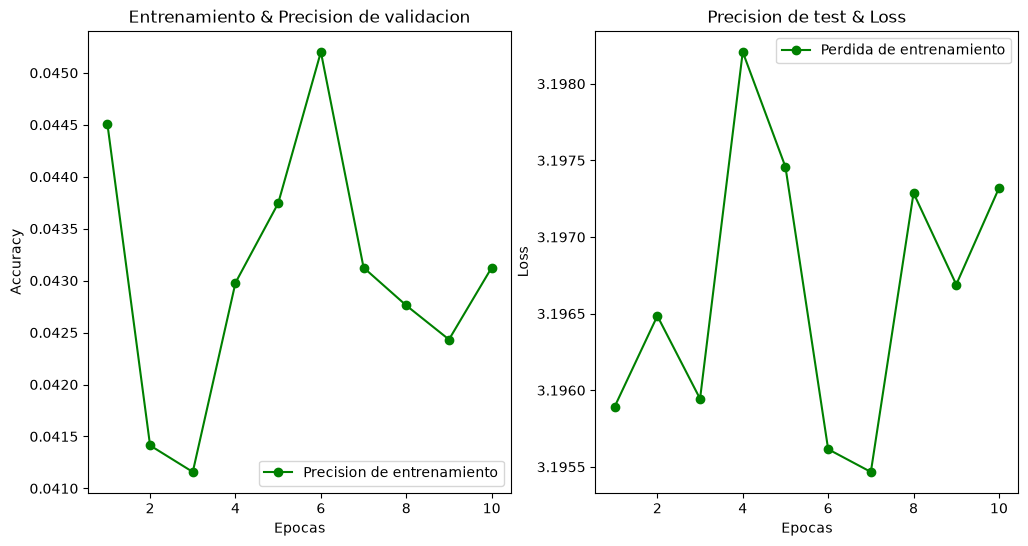

In [37]:
epochs = range(1, len(historial.history['accuracy'])+1) # aqui iteramos en base a las epocas de entrenamiento declaradas en la variable historial.
fig , ax = plt.subplots(1,2)
train_acc = historial.history['accuracy']
train_loss = historial.history['loss']
fig.set_size_inches(12,6)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Precision de entrenamiento')
ax[0].set_title('Entrenamiento & Precision de validacion')
ax[0].legend()
ax[0].set_xlabel("Epocas")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Perdida de entrenamiento')
ax[1].set_title('Precision de test & Loss')
ax[1].legend()
ax[1].set_xlabel("Epocas")
ax[1].set_ylabel("Loss")
plt.show()

# LOSS

In [ ]:
%matplotlib inline
plt.ylabel('Magnitud de error')
plt.xlabel('Epochs')
plt.plot(historial.history['loss'])
plt.grid(False)

# PREDICCIÓN

In [ ]:
# por comentar

In [ ]:
prediccion = red.predict(x_test)

prediccion = np.argmax(prediccion, axis=1)

print(prediccion.shape)
print(prediccion[:10])

In [ ]:
label_test.shape

In [ ]:
prediccion.shape

In [ ]:
y = label_test

labels = [i for i in range(25) if i != 9]

target_names = [f"class{i}" for i in labels]
print(y)
print(classification_report(y,prediccion,labels=labels,target_names=target_names))


In [ ]:
# verificacion de incosistencia
print(normalized_test.shape)
print(label_test.shape)
print(x_test.shape)
print(y.shape)
print(prediccion.shape)

In [ ]:
# comprobacion largo de train y test, esto nos indica que existan la equitas en entrenamiento, que las etiquetas existan realmentes en el tes
# y las clases que realmente tenemos, se realiza esta comprobacion dado que la clase 9 no se encuentra en 
print(np.unique(label_train))
print(np.unique(label_test))
print('Clases', len(np.unique(label_train)))
      

In [ ]:
cm = confusion_matrix(y,prediccion)